# Explore an Example NISAR GCOV Backscatter Time Series

<br>

This notebook introduces the analysis of multi-temporal SAR backscatter image data stacks using the NISAR L2 GCOV data product. GCOV data are a geocoded data product that provides radiometric and terrain corrected backscatter measurements in $\gamma^{0}$ at linear (power) scale.

**This notebook demonstrates:**
1. Accessing and loading of a GCOV times series via HTTPS requests
1. Subsetting to an area of interest
1. Saving the subset time series as a local Zarr Store
1. Converting between power and sB scales
1. Generating a time series animation and saving it as a gif
1. Calculating a time series of mean backscatter.  

<img src="https://asfopensarlab.github.io/opensarlab-notebook-assets/notebook_images/Nepalclimate.jpeg" width="400" align="right" /> 

This notebook will be access a SAR data stack over Pokhara, Nepal for an introduction to time series processing. The data were acquired by NISAR's L-band sensor and are available from the [Alaska Satellite Facility](https://www.asf.alaska.edu/). 

Nepal is an interesting site for this analysis due to the significant seasonality of precipitation that is characteristic for this region. Nepal is said to have five seasons: spring, summer, monsoon, autumn and winter. Precipitation is low in the winter (November - March) and peaks dramatically in the summer, with top rain rates in July, August, and September (see figure to the right). As SAR is sensitive to changes in soil moisture, these weather patterns have a noticeable impact on the Radar Cross Section ($\sigma$) time series information.

We will analyze the variation of $\gamma^{0}$ values over time and will interpret them in the context of rainfall rates in the imaged area. 

:::{attention} Notes about the time series and this notebook

As of this writing (March 7, 2026), NISAR GCOV data are newly released and the time series is only composed of 5 time steps. As more data become available, the time series will grow, as well as the time it takes to load the data and process them.
:::

<hr>

## Overview
1. [Prerequisites](ts-prereqs)
1. [Search Time Series Data](gcov-ts-search)
1. [Load the Data with `xarray` and `fsspec` using HTTPS requests](gcov-ts-load)
1. [Save the time series as a local Zarr Store](gcov-ts-save)
1. [Load the time series from the local Zarr Store](gcov-ts-load-from-zarr)
1. [Data Conversion between dB and Power Scales](gcov-ts-convert-scale)
1. [SAR Time Series Animation](gcov-ts-animate)
1. [Calculate the Time Series of Means](gcov-ts-means)
1. [Summary](gcov-ts-summary)
1. [Resources and references](gcov-ts-resources)

<hr>

(ts-prereqs)=
## 1. Prerequisites

| Prerequisite | Importance | Notes |
| --- | --- | --- |
| [The `isce3` software environment for this cookbook](software_environment_docker.ipynb) | Necessary | |
| [How to search and access NISAR data in your {abbr}`AOI (area of interest)`](search_NISAR_GCOV_asf_search.ipynb) | Necessary | If you wish to process data in your AOI instead of the example data |
| [Familiarity with xarray](https://docs.xarray.dev/en/stable/) | Helpful | |
| [Familiarity with matplotlib](https://matplotlib.org/stable/index.html) | Helpful | |

- **Rough Notebook Time Estimate**: 15 minutes (this is based on a 5 image time series and will change as more data become available)
 
<hr>

(gcov-ts-search)= 
## 2. Search Time Series Data

**If you have run this notebook before and already saved a local copy of the time series, skip ahead to section 5.**

### 2a. Search GCOV data and get a list of HTTPS product URLs with `asf_search`

In [1]:
import asf_search as asf
from datetime import datetime

import warnings
warnings.filterwarnings(
    "ignore",
    message="Parsing dates involving a day of month without a year specified",
)

session = asf.ASFSession()

start_date = datetime(2025, 11, 22)
end_date = datetime(2028, 1, 16)
area_of_interest = "POLYGON((83.8858 28.142,84.3554 28.142,84.3554 28.4825,83.8858 28.4825,83.8858 28.142))" # POINT or POLYGON as WKT (well-known-text)
pattern = r'^(?!.*QA_STATS).*' # used to remove static data files from results

opts=asf.ASFSearchOptions(**{
    "maxResults": 250,
    "intersectsWith": area_of_interest,
    "start": start_date,
    "end": end_date,
    "dataMaturity" : "PROVISIONAL",
    "processingLevel": "GCOV",
    "dataset": [
        "NISAR"
    ],
    "productionConfiguration": [
        "PR"
    ],
    'session': session,
    "frame": 16,
    "relativeOrbit": 26,
    "flightDirection": "ASCENDING",
})

response = asf.search(opts=opts)
hdf5_urls = response.find_urls(extension='.h5', pattern=pattern, directAccess=False)
print(f"Found {len(hdf5_urls)} GCOV products:")
hdf5_urls

Found 5 GCOV products:


['https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_PROVISIONAL_V1/NISAR_L2_PR_GCOV_024_026_A_016_4005_DHDH_A_20260627T234740_20260627T234815_P05023_N_F_J_001/NISAR_L2_PR_GCOV_024_026_A_016_4005_DHDH_A_20260627T234740_20260627T234815_P05023_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_PROVISIONAL_V1/NISAR_L2_PR_GCOV_025_026_A_016_4005_DHDH_A_20260709T234739_20260709T234814_P05023_N_F_J_001/NISAR_L2_PR_GCOV_025_026_A_016_4005_DHDH_A_20260709T234739_20260709T234814_P05023_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_PROVISIONAL_V1/NISAR_L2_PR_GCOV_026_026_A_016_4005_DHDH_A_20260721T234739_20260721T234813_P05023_N_F_J_001/NISAR_L2_PR_GCOV_026_026_A_016_4005_DHDH_A_20260721T234739_20260721T234813_P05023_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_PROVISIONAL_V1/NISAR_L2_PR_GCOV_028_026_A_016_4005_DHDH_A_20260814T234737_20260814T234812_P05023_N_F_J_001/NISAR_L2_PR_GCOV_028_026_

### 2b. Retain only the URL for the most recent version of each product in the search results

Data is occasionally re-released with an updated version. Versions are recorded as a [Composite Release Identifier (CRID)](https://nisar-docs.asf.alaska.edu/naming-conventions/) in a product's filename. We can use the CRID to retain only the most recent version of each product in the list of URLs.

In [2]:
import re

pattern = re.compile(r"(NISAR_L2_PR_GCOV(?:_[^_]+){9})_(P\d{5})")

latest_version_dict = {}

for url in hdf5_urls:
    m = pattern.search(url)
    if not m:
        continue

    product, crid = m.groups()

    if product not in latest_version_dict or crid > latest_version_dict[product][0]:
        latest_version_dict[product] = (crid, url)

hdf5_urls = [i[1] for i in latest_version_dict.values()]
print(f"Retained {len(hdf5_urls)} GCOV products:")
hdf5_urls

Retained 5 GCOV products:


['https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_PROVISIONAL_V1/NISAR_L2_PR_GCOV_024_026_A_016_4005_DHDH_A_20260627T234740_20260627T234815_P05023_N_F_J_001/NISAR_L2_PR_GCOV_024_026_A_016_4005_DHDH_A_20260627T234740_20260627T234815_P05023_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_PROVISIONAL_V1/NISAR_L2_PR_GCOV_025_026_A_016_4005_DHDH_A_20260709T234739_20260709T234814_P05023_N_F_J_001/NISAR_L2_PR_GCOV_025_026_A_016_4005_DHDH_A_20260709T234739_20260709T234814_P05023_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_PROVISIONAL_V1/NISAR_L2_PR_GCOV_026_026_A_016_4005_DHDH_A_20260721T234739_20260721T234813_P05023_N_F_J_001/NISAR_L2_PR_GCOV_026_026_A_016_4005_DHDH_A_20260721T234739_20260721T234813_P05023_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_PROVISIONAL_V1/NISAR_L2_PR_GCOV_028_026_A_016_4005_DHDH_A_20260814T234737_20260814T234812_P05023_N_F_J_001/NISAR_L2_PR_GCOV_028_026_

### 2c. Remove a problematic provisional GCOV product

There are obvious processing issues with the `NISAR_L2_PR_GCOV_025_026_A_016_4005_DHDH_A_20260709T234739_20260709T234814_P05023_N_F_J_001` and `NISAR_L2_PR_GCOV_026_026_A_016_4005_DHDH_A_20260721T234739_20260721T234813_P05023_N_F_J_001` products, so remove them from the results. This notebook currently uses provisional data, and issues such as these will be resolved when the validated data are released. See the [NISAR Data User Guide](https://nisar-docs.asf.alaska.edu/provisional-known-issues/) for information on known issues with the provisional data. 

If you wish to see how these scenes would impact the time series, skip the following code cell that removes them.

:::{figure} ../assets/NISAR_L2_PR_GCOV_025_026_A_016_4005_DHDH_A_20260709T234739_20260709T234814_P05023_N_F_J_001.png
:alt: Image of the NISAR_L2_PR_GCOV_025_026_A_016_4005_DHDH_A_20260709T234739_20260709T234814_P05023_N_F_J_001 product showing processing issues.
:width: 45%
:align: left

NISAR_L2_PR_GCOV_025_026_A_016_4005_DHDH_A_20260709T234739_20260709T234814_P05023_N_F_J_001
:::

In [3]:
exclude_dates = ["20260709", "20260721"]
hdf5_urls = [url for url in hdf5_urls if not any(date in url for date in exclude_dates)]
print(f"Retained {len(hdf5_urls)} GCOV products:")
hdf5_urls

Retained 3 GCOV products:


['https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_PROVISIONAL_V1/NISAR_L2_PR_GCOV_024_026_A_016_4005_DHDH_A_20260627T234740_20260627T234815_P05023_N_F_J_001/NISAR_L2_PR_GCOV_024_026_A_016_4005_DHDH_A_20260627T234740_20260627T234815_P05023_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_PROVISIONAL_V1/NISAR_L2_PR_GCOV_028_026_A_016_4005_DHDH_A_20260814T234737_20260814T234812_P05023_N_F_J_001/NISAR_L2_PR_GCOV_028_026_A_016_4005_DHDH_A_20260814T234737_20260814T234812_P05023_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_PROVISIONAL_V1/NISAR_L2_PR_GCOV_029_026_A_016_4005_DHDH_A_20260826T234737_20260826T234812_P05023_N_F_J_001/NISAR_L2_PR_GCOV_029_026_A_016_4005_DHDH_A_20260826T234737_20260826T234812_P05023_N_F_J_001.h5']

<hr>

(gcov-ts-load)=
## 3. Load the Data with `xarray` and `fsspec` using HTTPS requests

### 3a. Retrieve your Earthdata Login Bearer Token

:::{figure} ../assets/edl_token.png
:alt: Image of the Earthdata Login Generate Token web page
:width: 75%
:align: left

View or generate a Bearer Token in "Generate Token" tab of the Profile page in your Earthdata Login account: https://urs.earthdata.nasa.gov/profile
:::


In [4]:
from getpass import getpass

token = getpass("Enter your EDL Bearer Token")

Enter your EDL Bearer Token ········


### 3b. Lazily load the Frequency A data for each GCOV product into an `xarray.DataTree` 

Lazily load the frequencyA group of the GCOV data.

#### Notes on Chunking

This notebook utilizes [Dask chunking](https://docs.dask.org/en/latest/array-chunks.html) to break large arrays into smaller blocks. Chunking allows users to inspect and process subsets of a dataset without loading entire arrays into memory at once. This notebook uses a chunk size of 8 MB.

For additional benchmarking and recommendations for NISAR direct-access workflows, see Henry Rodman's [Reading NISAR granules directly from S3](https://gist.github.com/hrodmn/5a377531c19da6f6d2c2bb149c450b3d).

In [5]:
%%time
import fsspec
import xarray as xr
import rioxarray

group_path = "/science/LSAR/GCOV/grids/frequencyA" # change this to any GCOV HDF5 group you wish

fs = fsspec.filesystem(
    "http",
    headers = {"Authorization": f"Bearer {token}"},
    cache_type = "background",
    block_size = 8 * 1024 * 1024, # 8 MB
)

files = [fs.open(url, "rb") for url in hdf5_urls]

datatrees = [
    xr.open_datatree(
        f,
        engine="h5netcdf",
        decode_timedelta=False,
        phony_dims="access",
        chunks="auto",
        group=group_path,
    )
    for f in files
]

CPU times: user 1.14 s, sys: 577 ms, total: 1.72 s
Wall time: 16.9 s


### 3c. Create a list of datetimes for the `time` dimension of the time series

In [6]:
import re
from urllib.parse import urlparse
from datetime import datetime
from pathlib import PurePosixPath

NISAR_TS_RE = re.compile(r"_(\d{8}T\d{6})_")

def nisar_start_time_from_url(url: str) -> datetime:
    path = urlparse(url).path
    name = PurePosixPath(path).name
    
    m = NISAR_TS_RE.search(name)
    if not m:
        raise ValueError(f"No NISAR timestamp found in: {url}")
    
    return datetime.strptime(m.group(1), "%Y%m%dT%H%M%S")

dts = [nisar_start_time_from_url(url) for url in hdf5_urls]
dts

[datetime.datetime(2026, 6, 27, 23, 47, 40),
 datetime.datetime(2026, 8, 14, 23, 47, 37),
 datetime.datetime(2026, 8, 26, 23, 47, 37)]

### 3d. Convert the `Datatrees` into `DataArrays` that include a `time` dimension

In [7]:
%%time

dataarrays = [
    tree.ds.assign_coords(time=dt).expand_dims(time=1)
    for dt, tree in zip(dts, datatrees)
]

dataarrays[0].time

CPU times: user 11.6 ms, sys: 1.48 ms, total: 13.1 ms
Wall time: 12.6 ms


<xarray.DataArray 'time' (time: 1)> Size: 8B
array(['2026-06-27T23:47:40.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 8B 2026-06-27T23:47:40

### 3e. Extract the HHHH covariance layers and spatially subset them to an AOI 

In [8]:
hhhh =  [da.HHHH.rio.write_crs(f"EPSG:{da.isel(time=0).projection.item()}") for da in dataarrays]

bbox4326 = dict(minx=83.9633, miny=27.9427, maxx=84.3461, maxy=28.4555, crs="EPSG:4326")
hhhh_subset = [da.rio.clip_box(**bbox4326) for da in hhhh]

In [9]:
ts = xr.concat(hhhh_subset, dim="time")
ts

<xarray.DataArray 'HHHH' (time: 3, yCoordinates: 5784, xCoordinates: 3909)> Size: 271MB
dask.array<concatenate, shape=(3, 5784, 3909), dtype=float32, chunksize=(1, 3049, 3909), chunktype=numpy.ndarray>
Coordinates:
  * time          (time) datetime64[ns] 24B 2026-06-27T23:47:40 ... 2026-08-2...
  * yCoordinates  (yCoordinates) float64 46kB 3.152e+06 3.152e+06 ... 3.094e+06
  * xCoordinates  (xCoordinates) float64 31kB 7.902e+05 7.902e+05 ... 8.293e+05
    projection    int64 8B 0
Attributes:
    description:    Covariance between HH and HH
    long_name:      Geocoded polarimetric covariance term HHHH
    max_value:      214417.61
    mean_value:     0.97990304
    min_value:      1.2378029e-17
    sample_stddev:  105.54378
    units:          1
    valid_min:      0.0

### 3f. Visually confirm the subset AOI's location

Plot the subset bounds on a basemap to verify the expected location

In [11]:
from ipyleaflet import Map, TileLayer, Rectangle, LayersControl
import math

minx, miny, maxx, maxy = hhhh[0].rio.transform_bounds("EPSG:4326", densify_pts=21)
sub_minx, sub_miny, sub_maxx, sub_maxy = hhhh_subset[0].rio.transform_bounds(
    "EPSG:4326", densify_pts=21
)

def zoom_for_bounds(min_lon, min_lat, max_lon, max_lat, width=1600, height=700):
    def merc_y(lat):
        lat = max(min(lat, 85.051), -85.051)
        s = math.sin(math.radians(lat))
        return 0.5 - math.log((1 + s) / (1 - s)) / (4 * math.pi)

    lon_frac = (max_lon - min_lon) / 360
    lat_frac = abs(merc_y(max_lat) - merc_y(min_lat))

    zx = math.log2(width * 0.9 / (256 * lon_frac))
    zy = math.log2(height * 0.9 / (256 * lat_frac))
    return math.floor(min(zx, zy))

m = Map(
    center=((miny + maxy) / 2, (minx + maxx) / 2),
    zoom=zoom_for_bounds(minx, miny, maxx, maxy),
    scroll_wheel_zoom=True,
    layout={"height": "700px", "width": "75%"},
)

m.add(TileLayer(
    url="https://server.arcgisonline.com/ArcGIS/rest/services/"
        "World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attribution="Esri",
    name="Esri World Imagery",
))

m.add(TileLayer(
    url="https://tile.openstreetmap.org/{z}/{x}/{y}.png",
    attribution="© OpenStreetMap contributors",
    opacity=0.5,
    name="OpenStreetMap",
))

m.add(Rectangle(
    bounds=[(miny, minx), (maxy, maxx)],
    color="blue",
    fill=False,
    weight=3,
    name="Scene Extent",
))

m.add(Rectangle(
    bounds=[(sub_miny, sub_minx), (sub_maxy, sub_maxx)],
    color="red",
    fill=False,
    weight=3,
    name="Subset AOI",
))

m.add(LayersControl())
m

Map(center=[28.70679101076368, 82.88809429247945], controls=(ZoomControl(options=['position', 'zoom_in_text', …

<hr>

(gcov-ts-save)=
## 4. (Optional) Save the time series as a local Zarr Store

Up to this point, you have lazily loaded the time series data into xarray data structures. These hold only pointers to data stored remotely in an S3 Bucket. Accessing the values in a large dataset from S3 in Earthdata can be slow. If you are not careful in how you work with the them, you may access the same data multiple times, slowing your work even more. Additionally, Earthdata S3 Bucket credentials expire after one hour, so if you don't complete your work within that time, you may have to repeat many slow steps in your analysis.

**To mitigate these pain points, you can save your subset time series to a Zarr Store on your local volume.**
- Local data access is much faster than remote access.
  - It is still wise to avoid recomputing values via careful use of xarray.
- If you set down your work for the day or restart your notebook kernel or JupyterHub server, you can quickly reload your locally stored data.
- You are no longer time-constrained by short-lived Earthdata S3 Bucket credentials. 

### 4a. Create directories to hold the time series data and output plots

In [12]:
from pathlib import Path

time_series_example_dir = Path.home() / "NISAR_GCOV_time_series_example"

data_dir = time_series_example_dir / "data"
data_dir.mkdir(parents=True, exist_ok=True)

### 4b. Save the time series as a Zarr Store

Until now, we have not accessed any values in our xarray data structures; we have manipulated pointers to the data. To save the data to a Zarr Store, all values in the subset must be accessed, which is slow over the network. 

In [13]:
%%time

ts = ts.chunk({"time": 1, "yCoordinates": 2048, "xCoordinates": 2048})
zarr_ts_path = data_dir / "pokhara_timeseries.zarr"
ts.to_zarr(data_dir / "pokhara_timeseries.zarr", mode="w", consolidated=False)

CPU times: user 9.13 s, sys: 5.54 s, total: 14.7 s
Wall time: 2min 1s


### 4c. Close the open files to the data

In [14]:
for f in files:
    f.close()

<hr>

(gcov-ts-load-from-zarr)=
## 5. (Optional) Load the time series from the local Zarr Store

If you have opted to run Step 4 of this notebook and saved a local Zarr Store, you can start the notebook from from this step when re-running it.

### 5a. Load the Zarr Store

In [15]:
%%time

from pathlib import Path
import xarray as xr

time_series_example_dir = Path.home() / "NISAR_GCOV_time_series_example"
data_dir = time_series_example_dir / "data"
plot_dir = time_series_example_dir / "plots"
zarr_ts_path = data_dir / "pokhara_timeseries.zarr"

ts = xr.open_zarr(zarr_ts_path, consolidated=False).HHHH
ts

CPU times: user 5.43 ms, sys: 2.67 ms, total: 8.1 ms
Wall time: 8.2 ms


<xarray.DataArray 'HHHH' (time: 3, yCoordinates: 5784, xCoordinates: 3909)> Size: 271MB
dask.array<open_dataset-HHHH, shape=(3, 5784, 3909), dtype=float32, chunksize=(1, 2048, 2048), chunktype=numpy.ndarray>
Coordinates:
  * time          (time) datetime64[ns] 24B 2026-06-27T23:47:40 ... 2026-08-2...
  * yCoordinates  (yCoordinates) float64 46kB 3.152e+06 3.152e+06 ... 3.094e+06
  * xCoordinates  (xCoordinates) float64 31kB 7.902e+05 7.902e+05 ... 8.293e+05
Attributes:
    description:    Covariance between HH and HH
    long_name:      Geocoded polarimetric covariance term HHHH
    max_value:      214417.609375
    mean_value:     0.9799030423164368
    min_value:      1.23780291207364e-17
    sample_stddev:  105.54377746582031
    units:          1
    valid_min:      0.0
    grid_mapping:   projection

<hr>


(gcov-ts-convert-scale)=
## 6. Data Conversion between dB and Power Scales

Focused SAR image data may come in uncalibrated digital numbers (DN) and need to be calibrated to correspond to proper radar cross section information. However, NISAR data is already radiometrically calibrated and has a scaling factor of 1.0, so we do not need to worry about this. 

The data at hand are radiometrically terrain corrected images, which are expressed as terrain flattened $\gamma^0$ backscatter coefficients. For forest and land cover monitoring applications $\gamma^o$ is the preferred metric.

We often visualize backscatter in log scale (dB), as plotting in a linear (Power) scale may obscure subtleties. However, we must compute statistics in linear scale, so you may have need to convert back and forth between Power and dB.

NISAR GCOV data are provided in Power scale.

### 6a. Convert the `HHHH` data from power to dB

:::{tip} The latency of this step depends on whether you are accessing data locally or over the network

If you are loading data from a local Zarr store, saved in step 4 and loaded in step 5, this step will run quickly. 

If you skipped steps 4-5 and are using the lazily loaded time series, then this is the first step in which data values will be accessed over the network, and it will take much longer. However, by calling `ts_db.load()` below we save the data values to memory, so the remaining steps in the notebook will execute efficiently.
:::

To convert from power to dB, apply: $\gamma^o_{dB} = 10 {\log_{10}(\gamma^o_{power})}$

In [16]:
%%time
import numpy as np

ts_db = db = 10 * np.log10(ts.where(ts > 0)) # avoid log10 on values <= 0 to avoid division by zero warnings

# load ts_db values into memory once now to avoid multiple loads in subsequent code cells
ts_db.load()
ts_db

CPU times: user 425 ms, sys: 195 ms, total: 621 ms
Wall time: 129 ms


<xarray.DataArray 'HHHH' (time: 3, yCoordinates: 5784, xCoordinates: 3909)> Size: 271MB
array([[[-1.4818256e+00, -4.8887072e+00, -3.0237732e+00, ...,
         -1.3375240e+02, -1.3611551e+02, -1.3436734e+02],
        [-1.7579482e+00,  3.1646461e+00, -1.5526848e+00, ...,
         -1.3614502e+02, -1.3771570e+02, -1.3526126e+02],
        [-3.6732564e+00,  1.2503150e+00,  1.9341269e+00, ...,
         -1.3390053e+02, -1.3747400e+02, -1.3692088e+02],
        ...,
        [-5.8600545e+00, -6.6004438e+00, -4.0792198e+00, ...,
                    nan,            nan,            nan],
        [ 1.2157423e+00, -6.1009936e+00, -3.5677841e+00, ...,
                    nan,            nan,            nan],
        [ 8.7721515e-01, -2.5660145e-01, -1.8503108e+00, ...,
                    nan,            nan,            nan]],

       [[-2.1151447e+00, -4.1643438e+00, -6.6581559e+00, ...,
         -1.3344954e+02, -1.3245280e+02, -1.3641803e+02],
        [-2.3745129e+00,  1.6483117e+00, -1.5444969e+00, ...,
         -1.3457983e+02, -1.3353259e+02, -1.3366875e+02],
        [-8.9351454e+00, -3.4749417e+00, -4.1831601e-01, ...,
         -1.3714528e+02, -1.3582440e+02, -1.3439333e+02],
...
         -1.1636057e+00, -5.4118009e+00, -5.0932636e+00],
        [ 2.9114163e-01, -2.9788046e+00, -3.0082462e+00, ...,
         -8.1481113e+00, -7.9607720e+00, -5.9628682e+00],
        [ 4.3817449e+00, -2.8060532e-01,  4.0888757e-01, ...,
         -4.9872465e+00, -5.0327730e+00, -6.0121255e+00]],

       [[-1.2439367e-01, -2.7299547e+00, -6.8742681e+00, ...,
         -1.3549055e+02, -1.3350592e+02, -1.3303865e+02],
        [-5.3666472e+00, -1.2463236e-01, -2.2164557e+00, ...,
         -1.3446065e+02, -1.3300075e+02, -1.3312578e+02],
        [-1.0880095e+01, -7.3736658e+00, -4.9387172e-01, ...,
         -1.3110870e+02, -1.3235745e+02, -1.3564307e+02],
        ...,
        [-5.8810525e+00, -5.1974344e+00, -6.0668015e+00, ...,
         -9.5197052e-01, -2.6641676e+00, -3.9361935e+00],
        [-1.8990797e-01, -2.3515618e+00, -2.9283750e+00, ...,
         -4.1605420e+00,  3.5175830e-01, -5.2153449e+00],
        [ 4.8103108e+00,  2.4103024e+00, -4.3498480e-01, ...,
         -2.5006602e+00, -1.1195194e+00, -2.8253639e+00]]],
      shape=(3, 5784, 3909), dtype=float32)
Coordinates:
  * time          (time) datetime64[ns] 24B 2026-06-27T23:47:40 ... 2026-08-2...
  * yCoordinates  (yCoordinates) float64 46kB 3.152e+06 3.152e+06 ... 3.094e+06
  * xCoordinates  (xCoordinates) float64 31kB 7.902e+05 7.902e+05 ... 8.293e+05
Attributes:
    description:    Covariance between HH and HH
    long_name:      Geocoded polarimetric covariance term HHHH
    max_value:      214417.609375
    mean_value:     0.9799030423164368
    min_value:      1.23780291207364e-17
    sample_stddev:  105.54377746582031
    units:          1
    valid_min:      0.0
    grid_mapping:   projection

### 6b. Plot the histogram of the dB data and confirm a normal distribution

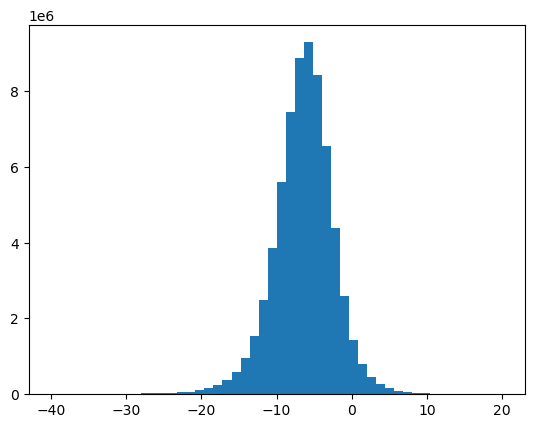

In [17]:
import matplotlib.pyplot as plt

ax = ts_db.values.ravel()
ax = ax[(ax < 20) & (ax > -40)]
plt.hist(ax, bins=50)
plt.show()

## 6c. Convert from dB back to power

While dB-scaled images are often visually pleasing, they are not a good basis for mathematical operations. For instance, when computing the mean backscatter, we cannot simply average data in log scale. 
    
Please note that the correct scale in which operations need to be performed is the power scale. This is critical, e.g. when speckle filters are applied, when spatial operations like block averaging are performed, or other statistics across time series are analyzed.

To convert from dB to power, apply: $\gamma^o_{pwr} = 10^{\frac{\gamma^o_{dB}}{10}}$

In [18]:
ts_pwr = np.power(10.0, ts_db/10.0)
ts_pwr

<xarray.DataArray 'HHHH' (time: 3, yCoordinates: 5784, xCoordinates: 3909)> Size: 271MB
array([[[7.1091461e-01, 3.2443619e-01, 4.9845123e-01, ...,
         4.2146415e-14, 2.4459564e-14, 3.6581862e-14],
        [6.6712189e-01, 2.0723572e+00, 6.9940948e-01, ...,
         2.4293945e-14, 1.6921147e-14, 2.9776532e-14],
        [4.2921448e-01, 1.3336182e+00, 1.5610352e+00, ...,
         4.0733076e-14, 1.7889563e-14, 2.0319446e-14],
        ...,
        [2.5941467e-01, 2.1875381e-01, 3.9091113e-01, ...,
                   nan,           nan,           nan],
        [1.3230438e+00, 2.4541473e-01, 4.3976593e-01, ...,
                   nan,           nan,           nan],
        [1.2238312e+00, 9.4262695e-01, 6.5308380e-01, ...,
                   nan,           nan,           nan]],

       [[6.1444855e-01, 3.8332367e-01, 2.1586609e-01, ...,
         4.5190427e-14, 5.6848596e-14, 2.2813779e-14],
        [5.7882690e-01, 1.4616089e+00, 7.0072937e-01, ...,
         3.4835094e-14, 4.4334409e-14, 4.2966038e-14],
        [1.2778665e-01, 4.4926834e-01, 9.0817261e-01, ...,
         1.9296205e-14, 2.6155295e-14, 3.6363612e-14],
...
         7.6496124e-01, 2.8762054e-01, 3.0950928e-01],
        [1.0693359e+00, 5.0363922e-01, 5.0023651e-01, ...,
         1.5317535e-01, 1.5992737e-01, 2.5334549e-01],
        [2.7426758e+00, 9.3743134e-01, 1.0987244e+00, ...,
         3.1715778e-01, 3.1385040e-01, 2.5048831e-01]],

       [[9.7176361e-01, 5.3334045e-01, 2.0538712e-01, ...,
         2.8245217e-14, 4.4607547e-14, 4.9674623e-14],
        [2.9062656e-01, 9.7171021e-01, 6.0028076e-01, ...,
         3.5804289e-14, 5.0110117e-14, 4.8687986e-14],
        [8.1656456e-02, 1.8307686e-01, 8.9250946e-01, ...,
         7.7469301e-14, 5.8110492e-14, 2.7270541e-14],
        ...,
        [2.5816345e-01, 3.0217361e-01, 2.4735452e-01, ...,
         8.0316162e-01, 5.4148102e-01, 4.0399933e-01],
        [9.5721436e-01, 5.8189392e-01, 5.0952148e-01, ...,
         3.8365936e-01, 1.0843658e+00, 3.0093002e-01],
        [3.0271301e+00, 1.7419282e+00, 9.0469360e-01, ...,
         5.6225586e-01, 7.7276611e-01, 5.2175140e-01]]],
      shape=(3, 5784, 3909), dtype=float32)
Coordinates:
  * time          (time) datetime64[ns] 24B 2026-06-27T23:47:40 ... 2026-08-2...
  * yCoordinates  (yCoordinates) float64 46kB 3.152e+06 3.152e+06 ... 3.094e+06
  * xCoordinates  (xCoordinates) float64 31kB 7.902e+05 7.902e+05 ... 8.293e+05
Attributes:
    description:    Covariance between HH and HH
    long_name:      Geocoded polarimetric covariance term HHHH
    max_value:      214417.609375
    mean_value:     0.9799030423164368
    min_value:      1.23780291207364e-17
    sample_stddev:  105.54377746582031
    units:          1
    valid_min:      0.0
    grid_mapping:   projection

## Plot the histogram of the Power-scale data

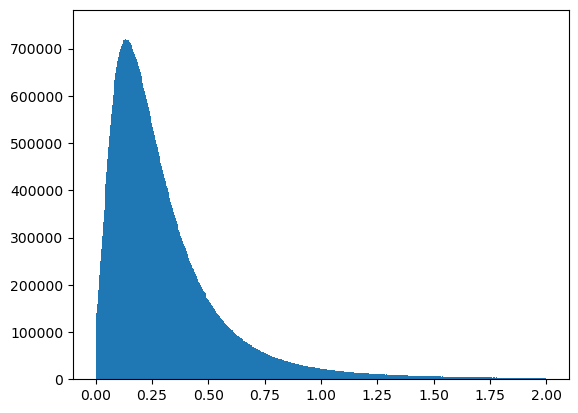

In [19]:
ax = ts_pwr.values.ravel()
ax = ax[ax < 2]
plt.hist(ax, bins=500)
plt.show()

<hr>

(gcov-ts-animate)=
## 7. SAR Time Series Animation

This section introduces you to the handling and analysis of SAR time series stacks. A focus will be put on time series visualizations, which allow us to inspect time series in more depth. 

Animations will display interactively and be saved as gifs.

### 7a. Create a Time Series Animation from the dB Subset

In [20]:
%%capture
from matplotlib.animation import FuncAnimation
from matplotlib.animation import FFMpegWriter, PillowWriter

vmin = ts_db.quantile(0.05, skipna=True).values.item()
vmax = ts_db.quantile(0.95, skipna=True).values.item()

fig, ax = plt.subplots(figsize=(6, 6), )
frame_0 = ts_db.isel(time=0).values
im = ax.imshow(frame_0, vmin=vmin, vmax=vmax, origin="upper", cmap="grey")
cb = fig.colorbar(im, ax=ax, label="γ⁰ (dB)")
ax.set_title(np.datetime_as_string(ts_db.time.values[0], unit='s'))
ax.set_axis_off()

def animate(i):
    frame = ts_db.isel(time=i).values
    im.set_data(frame)
    ax.set_title(np.datetime_as_string(ts_db.time.values[i], unit='s'))
    return (im,)

ani = FuncAnimation(fig, animate, frames=ts_db.sizes["time"], interval=300, blit=False)

plt.show()

### 7b. Create a javascript animation of the time-series running inline in the notebook:

In [21]:
from IPython.display import HTML

HTML(ani.to_jshtml())

### 7c. Save the animation (animation.gif):

In [22]:
from pathlib import Path

time_series_example_dir = Path.home() / "NISAR_GCOV_time_series_example"
plot_dir = time_series_example_dir / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

ani.save(plot_dir / "timeseries_animation.gif", writer=PillowWriter(fps=3))

<hr>

(gcov-ts-means)=
## 8. Calculate the Time Series of Means

Calculate the Time Series of Means Across the HHHH

To create the time series of means:
1. Compute subset means for each time-step using data in power scale ($\gamma^o_{pwr}$) .
1. Convert the resulting mean values into dB scale for visualization.

### 8a. Identify the axis on which to take the means

Note that the Dataset dimensions are ('time', 'yCoordinates', 'xCoordinates')

In [23]:
ts_pwr.dims

('time', 'yCoordinates', 'xCoordinates')

### 8b. Compute the means in power scale:

Since we want to take the means across the spatial dimensions (dims 1 and 2) on each day, we should pass `axis=(1, 2)` to `np.mean`.

This will compute the backscatter means spatially, while leaving the time dimension in place.

In [24]:
means_pwr = np.mean(ts_pwr, axis=(1, 2))
means_pwr

<xarray.DataArray 'HHHH' (time: 3)> Size: 12B
array([0.5542437, 0.5208964, 0.5671106], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 24B 2026-06-27T23:47:40 ... 2026-08-26T23:...
Attributes:
    description:    Covariance between HH and HH
    long_name:      Geocoded polarimetric covariance term HHHH
    max_value:      214417.609375
    mean_value:     0.9799030423164368
    min_value:      1.23780291207364e-17
    sample_stddev:  105.54377746582031
    units:          1
    valid_min:      0.0
    grid_mapping:   projection

### 8c. Convert the resulting mean value time-series to dB scale for visualization

In [25]:
means_db = 10 * np.log10(means_pwr.where(means_pwr > 0))
means_db

<xarray.DataArray 'HHHH' (time: 3)> Size: 12B
array([-2.5629926, -2.8324866, -2.4633224], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 24B 2026-06-27T23:47:40 ... 2026-08-26T23:...
Attributes:
    description:    Covariance between HH and HH
    long_name:      Geocoded polarimetric covariance term HHHH
    max_value:      214417.609375
    mean_value:     0.9799030423164368
    min_value:      1.23780291207364e-17
    sample_stddev:  105.54377746582031
    units:          1
    valid_min:      0.0
    grid_mapping:   projection

### 8d. Plot the time series of means

Plot both the Power and dB time series of means

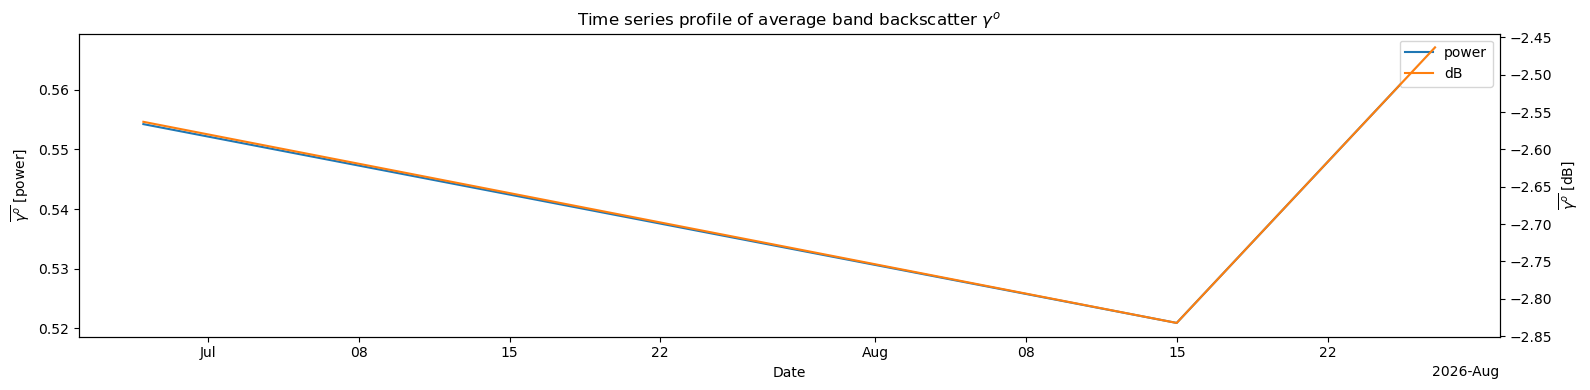

In [26]:
import matplotlib.dates as mdates

fig, ax1 = plt.subplots(figsize=(16, 4))

# left y-axis: power
means_pwr.plot.line(ax=ax1, x="time", label="power")
ax1.set_xlabel("Date")
ax1.set_ylabel(r"$\overline{\gamma^o}$ [power]")

# right y-axis: dB
ax2 = ax1.twinx()
means_db.plot.line(ax=ax2, x='time', color='tab:orange', label='dB')
ax2.set_ylabel(r'$\overline{\gamma^o}$ [dB]')

ax2.set_xlim(ax1.get_xlim())
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right')

ax1.set_title(r'Time series profile of average band backscatter $\gamma^o$')
ax2.set_title("")
plt.tight_layout()
plt.show()


### 8e. Create Two-Panel Figure, Animating Both the Imagery and the Daily Global Means $\mu_{\gamma^0_{dB}}$

In [27]:
%%capture
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as an
import matplotlib.dates as mdates

vmin = ts_db.quantile(0.05, skipna=True).values.item()
vmax = ts_db.quantile(0.95, skipna=True).values.item()

t_num = mdates.date2num(ts_db.time.values)                    
means = np.asarray(means_db.compute().values).reshape(-1)

fig = plt.figure(figsize=(12,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

# Image axis
frame_0 = ts_db.isel(time=0).values
im = ax1.imshow(frame_0, vmin=vmin, vmax=vmax, origin="upper", cmap="grey")
ax1.set_title(np.datetime_as_string(ts_db.time.values[0], unit='D'))
ax1.set_axis_off()

# Line axis
(l,) = ax2.plot([], [], lw=3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax2.set_xlim(t_num.min(), t_num.max())

ax2.set_ylim(np.nanmin(means)-0.5, np.nanmax(means)+0.5)
ax2.set_ylabel(r"Backscatter Means $\mu_{\gamma^0_{dB}}$")
ax2.set_title(str(ts_db.time.values[0].astype("datetime64[D]")))

def init():
    l.set_data([], [])
    return im, l

def animate(i):
    ts = str(ts_db.time.values[i].astype("datetime64[D]"))
    ax1.set_title(ts)
    ax2.set_title(ts)

    im.set_data(ts_db.isel(time=i).values)
    l.set_data(t_num[:i+1], means[:i+1])

    return im, l

ani = an.FuncAnimation(fig, animate, frames=len(ts_db.time), init_func=init, interval=400, blit=False)
plt.tight_layout()
plt.show()

### 8f. Create a javascript animation of the time-series running inline in the notebook:

In [28]:
HTML(ani.to_jshtml())

### Save the animated time-series and histogram (animation_histogram.gif):

In [29]:
from pathlib import Path

time_series_example_dir = Path.home() / "NISAR_GCOV_time_series_example"
plot_dir = time_series_example_dir / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

ani.save(plot_dir / 'animation_histogram.gif', writer='pillow', fps=2)

<hr>

(gcov-ts-summary)=
## 9. Summary
**Having completed this workflow, you have:**
- Searched and downloaded a NISAR GCOV time series
- Subset the data to a specific polarization and AOI
- Converted the data between linear and logarithmic scales
- Generated a backscatter time series animation and output it as a gif
- Calculated the time series of means, animated it, and output it as a gif

<hr>

(gcov-ts-resources)=
## 10. Resources and references
 - [NISAR Data User Guide](https://nisar-docs.asf.alaska.edu/)
 - [UAF GEOS657 Microwave Remote Sensing class website](https://radar.community.uaf.edu/)
 - **Authors:**
   - Alex Lewandowski; [Alaska Satellite Facility](https://asf.alaska.edu/)
   - Adapted for NISAR data from [earlier work](https://github.com/ASFOpenSARlab/opensarlab-notebooks/blob/master/SAR_Training/English/Master/Time_Series_Example.ipynb) by: 
     -  Franz J Meyer; [University of Alaska Fairbanks](https://www.uaf.edu/uaf/)
     -  Josef Kellndorfer, [Earth Big Data, LLC](http://earthbigdata.com/)
